In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
humansintheloop_semantic_segmentation_of_aerial_imagery_path = kagglehub.dataset_download('humansintheloop/semantic-segmentation-of-aerial-imagery')

print('Data source import complete.')
print(humansintheloop_semantic_segmentation_of_aerial_imagery_path)

Using Colab cache for faster access to the 'semantic-segmentation-of-aerial-imagery' dataset.
Data source import complete.
/kaggle/input/semantic-segmentation-of-aerial-imagery


# Лабораторная работа 1 (CV) — Семантическая сегментация

**Выбранный датасет:** [Semantic Segmentation of Aerial Imagery (Dubai Dataset)](https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery/data?select=Semantic+segmentation+dataset)

**Задача:** Семантическая сегментация спутниковых снимков для картографии и урбанистики.


In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.0 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


##  Подготовка данных



In [ ]:
base_path = humansintheloop_semantic_segmentation_of_aerial_imagery_path

DATA_DIR = os.path.join(base_path, "Semantic segmentation dataset")

classes_info = [
    {'name': 'Water', 'color': [80, 227, 194]},      # #50E3C2
    {'name': 'Land', 'color': [245, 166, 35]},       # #F5A623
    {'name': 'Road', 'color': [222, 89, 127]},       # #DE597F
    {'name': 'Building', 'color': [208, 2, 27]},     # #D0021B
    {'name': 'Vegetation', 'color': [65, 117, 5]},   # #417505
    {'name': 'Unlabeled', 'color': [155, 155, 155]}  # #9B9B9B
]

COLORS = np.array([c['color'] for c in classes_info])
CLASS_NAMES = [c['name'] for c in classes_info]
NUM_CLASSES = len(classes_info)

def rgb_to_mask(img, colors):
    """Преобразует RGB-маску в 2D маску с индексами классов."""
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    for idx, color in enumerate(colors):
        diff = np.abs(img - color).sum(axis=-1)
        mask[diff < 10] = idx
    return mask

In [ ]:
train_imgs, train_masks = [], []
val_imgs, val_masks = [], []

if DATA_DIR is not None:
    for tile_idx in range(1, 9):
        tile_dir = os.path.join(DATA_DIR, f"Tile {tile_idx}")
        images_dir = os.path.join(tile_dir, "images")
        masks_dir = os.path.join(tile_dir, "masks")

        if os.path.exists(images_dir) and os.path.exists(masks_dir):
            imgs = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) +
                          glob.glob(os.path.join(images_dir, "*.png")))

            tile_imgs, tile_msks = [], []
            for img_path in imgs:
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                msk_path_png = os.path.join(masks_dir, base_name + ".png")
                msk_path_jpg = os.path.join(masks_dir, base_name + ".jpg")

                if os.path.exists(msk_path_png):
                    tile_imgs.append(img_path)
                    tile_msks.append(msk_path_png)
                elif os.path.exists(msk_path_jpg):
                    tile_imgs.append(img_path)
                    tile_msks.append(msk_path_jpg)

            if 1 <= tile_idx <= 6:
                train_imgs.extend(tile_imgs)
                train_masks.extend(tile_msks)
            elif 7 <= tile_idx <= 8:
                val_imgs.extend(tile_imgs)
                val_masks.extend(tile_msks)

print(f"Train size: {len(train_imgs)} (Тайлы 1-6)")
print(f"Validation size: {len(val_imgs)} (Тайлы 7-8)")

if len(train_imgs) == 0:
    raise ValueError("Датасет не найден.")

Train size: 54 (Тайлы 1-6)
Validation size: 18 (Тайлы 7-8)


In [ ]:
class DubaiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask_rgb = cv2.imread(self.mask_paths[idx])
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

        mask = rgb_to_mask(mask_rgb, COLORS)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        return img, mask.long()

In [ ]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = DubaiDataset(train_imgs, train_masks, transform=train_transform)
val_dataset = DubaiDataset(val_imgs, val_masks, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

## Выбор Метрик
**Mean Intersection over Union** используется в качестве основной метрики оценки качества, так как она наиболее устойчива к сильному дисбалансу классов, типичному для спутниковых снимков. В отличие от обычной accuracy, IoU строго оценивает совпадение предсказания с истинной маской, одинаково штрафуя модель как за пропуск объекта (недолет), так и за выделение лишнего (перелет), а усреднение по классам mIoU гарантирует, что качество сегментации мелких объектов признается таким же важным, как и крупных.

 **Cross-Entropy Loss** выбрана в качестве функции потерь для оптимизации весов модели, поскольку она является стандартом и обеспечивает высокую стабильность градиентов в задачах независимой попиксельной многоклассовой классификации. Ключевой особенностью ее применения в данном коде является использование параметра ignore_index=5 - это позволяет полностью исключить из вычисления ошибки неразмеченные или спорные области сканирования, заставляя модель учиться только на достоверно размеченных данных.

## Создание бейзлайна
Используем `segmentation_models.pytorch` для загрузки архитектуры Unet с энкодером ResNet34.

In [ ]:
import json

criterion = nn.CrossEntropyLoss(ignore_index=5)


def calculate_iou(pred_mask, true_mask, num_classes, ignore_index=5):
    ious = []
    pred_mask = torch.argmax(pred_mask, dim=1)
    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_inds = pred_mask == cls
        target_inds = true_mask == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    return np.nanmean(ious)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, model_name="model"):
    history = {'train_loss': [], 'val_loss': [], 'val_mIoU': []}
    best_iou = 0.0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0

        total_intersection = torch.zeros(NUM_CLASSES, dtype=torch.float64, device=device)
        total_union = torch.zeros(NUM_CLASSES, dtype=torch.float64, device=device)

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)

                for cls in range(NUM_CLASSES):
                    if cls == 5:
                        continue

                    pred_inds = preds == cls
                    target_inds = masks == cls

                    intersection = (pred_inds & target_inds).sum().to(torch.float64)
                    union = (pred_inds | target_inds).sum().to(torch.float64)

                    total_intersection[cls] += intersection
                    total_union[cls] += union

        val_loss /= len(val_loader.dataset)

        class_mask = torch.ones(NUM_CLASSES, dtype=torch.bool, device=device)
        class_mask[5] = False
        valid_mask = class_mask & (total_union > 0)

        if valid_mask.any():
            val_iou = (total_intersection[valid_mask] / total_union[valid_mask]).mean().item()
        else:
            val_iou = 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mIoU'].append(val_iou)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"--> Сохранены улучшенные веса: {best_iou:.4f}")

    with open(f'{model_name}_history.json', 'w') as f:
        json.dump(history, f)

    print(f"Обучение {model_name} завершено.")
    return history

In [ ]:
print("Инициализация сверточной архитектуры: Unet + ResNet34")
model_cnn = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

NUM_EPOCHS = 5
history_cnn = train_model(
    model_cnn,
    train_loader,
    val_loader,
    criterion,
    optimizer_cnn,
    num_epochs=NUM_EPOCHS,
    model_name="baseline_cnn_resnet34"
)

Инициализация сверточной архитектуры: Unet + ResNet34


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch [1/5] | Train Loss: 1.6553 | Val Loss: 2.0125 | Val mIoU: 0.0483
--> Сохранены улучшенные веса: 0.0483
Epoch [2/5] | Train Loss: 1.3607 | Val Loss: 1.8046 | Val mIoU: 0.0861
--> Сохранены улучшенные веса: 0.0861
Epoch [3/5] | Train Loss: 1.1263 | Val Loss: 1.0922 | Val mIoU: 0.1590
--> Сохранены улучшенные веса: 0.1590
Epoch [4/5] | Train Loss: 0.9703 | Val Loss: 0.8967 | Val mIoU: 0.1892
--> Сохранены улучшенные веса: 0.1892
Epoch [5/5] | Train Loss: 0.8454 | Val Loss: 0.8199 | Val mIoU: 0.1965
--> Сохранены улучшенные веса: 0.1965
Обучение baseline_cnn_resnet34 завершено.


In [ ]:
print("Инициализация трансформерной архитектуры: Unet + MiT (Mix Vision Transformer)")
model_transformer = smp.Unet(
    encoder_name="mit_b0",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

optimizer_transformer = torch.optim.Adam(model_transformer.parameters(), lr=1e-4)

history_transformer = train_model(
    model_transformer,
    train_loader,
    val_loader,
    criterion,
    optimizer_transformer,
    num_epochs=NUM_EPOCHS,
    model_name="baseline_transformer_mit_b0"
)

Инициализация трансформерной архитектуры: Unet + MiT (Mix Vision Transformer)


config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Epoch [1/5] | Train Loss: 1.7645 | Val Loss: 1.7175 | Val mIoU: 0.0886
--> Сохранены улучшенные веса: 0.0886
Epoch [2/5] | Train Loss: 1.4951 | Val Loss: 1.3242 | Val mIoU: 0.1413
--> Сохранены улучшенные веса: 0.1413
Epoch [3/5] | Train Loss: 1.2554 | Val Loss: 1.1837 | Val mIoU: 0.1781
--> Сохранены улучшенные веса: 0.1781
Epoch [4/5] | Train Loss: 1.0420 | Val Loss: 0.8818 | Val mIoU: 0.1902
--> Сохранены улучшенные веса: 0.1902
Epoch [5/5] | Train Loss: 0.8692 | Val Loss: 0.7200 | Val mIoU: 0.1958
--> Сохранены улучшенные веса: 0.1958
Обучение baseline_transformer_mit_b0 завершено.


## Графики

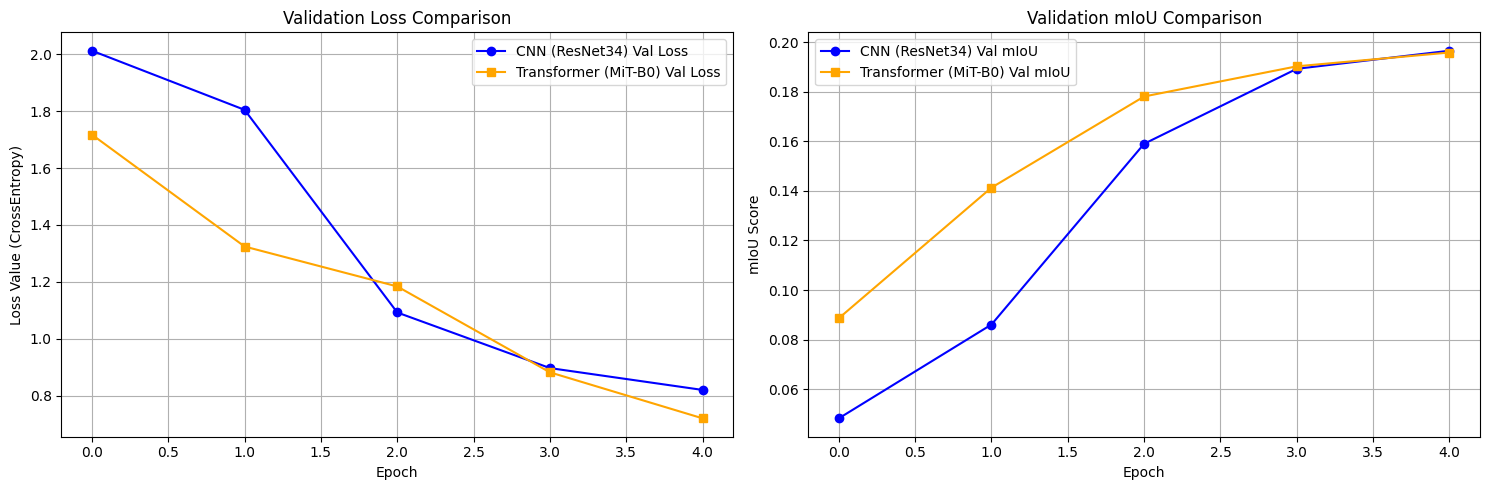

Лучший mIoU у CNN на валидации: 0.1965
Лучший mIoU у Transformer на валидации: 0.1958
  Сверточный бейзлайн показал себя лучше.


In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn['val_loss'], label='CNN (ResNet34) Val Loss', marker='o', color='blue')
plt.plot(history_transformer['val_loss'], label='Transformer (MiT-B0) Val Loss', marker='s', color='orange')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss Value (CrossEntropy)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_cnn['val_mIoU'], label='CNN (ResNet34) Val mIoU', marker='o', color='blue')
plt.plot(history_transformer['val_mIoU'], label='Transformer (MiT-B0) Val mIoU', marker='s', color='orange')
plt.title('Validation mIoU Comparison')
plt.xlabel('Epoch')
plt.ylabel('mIoU Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

best_cnn_iou = max(history_cnn['val_mIoU'])
best_tf_iou = max(history_transformer['val_mIoU'])

print(f"Лучший mIoU у CNN на валидации: {best_cnn_iou:.4f}")
print(f"Лучший mIoU у Transformer на валидации: {best_tf_iou:.4f}")

if best_cnn_iou > best_tf_iou:
    print("  Сверточный бейзлайн показал себя лучше.")
else:
    print("  Трансформерный бейзлайн показал себя лучше.")

### Вывод
Обе базовые архитектуры (свёрточная Unet+ResNet34 и трансформерная Unet+MiT-B0) продемонстрировали схожую динамику обучения: за 5 эпох метрика val_mIoU выросла практически до одинаковых значений (0.1965 у свёрточной против 0.1958 у трансформерной). Трансформерная модель стартовала с чуть более высоким качеством на первой эпохе и показала более низкое значение функции потерь на валидации в конце (val_loss 0.7200 против 0.8199), однако итоговое качество сегментации по mIoU оказалось идентичным. Это указывает на то, что за короткое время обучения (5 эпох) ни одна из архитектур не получила явного преимущества, и обе требуют либо увеличения числа эпох, либо применения методов регуляризации и аугментаций для дальнейшего существенного роста качества.

## Улучшение бейзлайна

In [ ]:
train_transform_improved = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform_improved = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset_improved = DubaiDataset(train_imgs, train_masks, transform=train_transform_improved)
val_dataset_improved = DubaiDataset(val_imgs, val_masks, transform=val_transform_improved)

train_loader_improved = DataLoader(train_dataset_improved, batch_size=4, shuffle=True, num_workers=2)
val_loader_improved = DataLoader(val_dataset_improved, batch_size=4, shuffle=False, num_workers=2)

improved_criterion = nn.CrossEntropyLoss(ignore_index=5)
print("UnetPlusPlus + resnet18 + Аугментации")

model_improved = smp.UnetPlusPlus(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-4)

history_improved = train_model(
    model_improved,
    train_loader_improved,
    val_loader_improved,
    criterion=improved_criterion,
    optimizer=optimizer_improved,
    num_epochs=10,
    model_name="improved_baseline_unetpp_resnet18"
)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


UnetPlusPlus + resnet18 + Аугментации


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch [1/10] | Train Loss: 2.5298 | Val Loss: 3.8053 | Val mIoU: 0.0034
--> Сохранены улучшенные веса: 0.0034
Epoch [2/10] | Train Loss: 2.1400 | Val Loss: 3.3962 | Val mIoU: 0.0026
Epoch [3/10] | Train Loss: 1.8410 | Val Loss: 2.1616 | Val mIoU: 0.0059
--> Сохранены улучшенные веса: 0.0059
Epoch [4/10] | Train Loss: 1.6927 | Val Loss: 1.9486 | Val mIoU: 0.0070
--> Сохранены улучшенные веса: 0.0070
Epoch [5/10] | Train Loss: 1.5699 | Val Loss: 1.7403 | Val mIoU: 0.0107
--> Сохранены улучшенные веса: 0.0107
Epoch [6/10] | Train Loss: 1.4708 | Val Loss: 1.5829 | Val mIoU: 0.0324
--> Сохранены улучшенные веса: 0.0324
Epoch [7/10] | Train Loss: 1.3844 | Val Loss: 1.4522 | Val mIoU: 0.1120
--> Сохранены улучшенные веса: 0.1120
Epoch [8/10] | Train Loss: 1.2919 | Val Loss: 1.3108 | Val mIoU: 0.1620
--> Сохранены улучшенные веса: 0.1620
Epoch [9/10] | Train Loss: 1.2036 | Val Loss: 1.2229 | Val mIoU: 0.1883
--> Сохранены улучшенные веса: 0.1883
Epoch [10/10] | Train Loss: 1.1153 | Val Loss: 1

## Вторая идея

In [ ]:
class DiceBCE(nn.Module):
    def __init__(self, ignore_index=5):
        super(DiceBCE, self).__init__()
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index)
        self.dice = smp.losses.DiceLoss(mode='multiclass', ignore_index=ignore_index)

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        dice_loss = self.dice(inputs, targets)
        return ce_loss + dice_loss

improved_criterion = DiceBCE(ignore_index=5)

In [ ]:
print("ЗАПУСК УЛУЧШЕННОГО БЕЙЗЛАЙНА ")

model_improved = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES
).to(device)

optimizer_improved = torch.optim.Adam(model_improved.parameters(), lr=1e-4)

history_improved = train_model(
    model_improved,
    train_loader_improved,
    val_loader_improved,
    criterion=improved_criterion,
    optimizer=optimizer_improved,
    num_epochs=8,
    model_name="improved_baseline_resnet34"
)

ЗАПУСК УЛУЧШЕННОГО БЕЙЗЛАЙНА 
Epoch [1/8] | Train Loss: 1.4917 | Val Loss: 1.4377 | Val mIoU: 0.0986
--> Сохранены улучшенные веса: 0.0986
Epoch [2/8] | Train Loss: 1.2294 | Val Loss: 1.4031 | Val mIoU: 0.1313
--> Сохранены улучшенные веса: 0.1313
Epoch [3/8] | Train Loss: 1.0265 | Val Loss: 0.9799 | Val mIoU: 0.1897
--> Сохранены улучшенные веса: 0.1897
Epoch [4/8] | Train Loss: 0.8681 | Val Loss: 0.7924 | Val mIoU: 0.1979
--> Сохранены улучшенные веса: 0.1979
Epoch [5/8] | Train Loss: 0.7489 | Val Loss: 0.6893 | Val mIoU: 0.1982
--> Сохранены улучшенные веса: 0.1982
Epoch [6/8] | Train Loss: 0.6561 | Val Loss: 0.6116 | Val mIoU: 0.1980
Epoch [7/8] | Train Loss: 0.5723 | Val Loss: 0.5409 | Val mIoU: 0.1976
Epoch [8/8] | Train Loss: 0.5017 | Val Loss: 0.4755 | Val mIoU: 0.1982
Обучение improved_baseline_resnet34 завершено.


### Вывод
Сравнение двух подходов к улучшению бейзлайна показало, что вторая гипотеза (тяжелый энкодер resnet34 с добавлением DiceLoss к перекрестной энтропии) сходится значительно быстрее и стабильнее, чем первая (смена архитектуры на UnetPlusPlus с легким resnet18 и сильными пространственными аугментациями). Первая концепция стартует с крайне низким качеством (mIoU 0.0034) и лишь к 10-й эпохе достигает 0.1954, испытывая трудности из-за сильных искажений данных. Вторая гипотеза уже к 4-й эпохе превосходит этот результат (0.1979) и демонстрирует непрерывное уверенное падение функции потерь (с 1.4377 до 0.4755), при этом метрика mIoU стабилизируется на отметке ~0.1982, что говорит о правильном симбиозе более сложной сети и балансирующей функции потерь.

## Имплементация алгоритма машинного обучения

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv2D -> BatchNorm2D -> ReLU) * 2 блока подряд"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class MicroUNet(nn.Module):
    def __init__(self, num_classes=6):
        super(MicroUNet, self).__init__()

        self.enc1 = DoubleConv(3, 16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.enc3 = DoubleConv(32, 64)

        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64, 32)

        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(32, 16)

        self.final_conv = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        d2 = self.upconv2(e3)
        d2 = torch.cat([e2, d2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([e1, d1], dim=1)
        d1 = self.dec1(d1)

        out = self.final_conv(d1)
        return out

def check_model():
    dummy_input = torch.randn(2, 3, 512, 512).to(device)
    model = MicroUNet(num_classes=NUM_CLASSES).to(device)
    output = model(dummy_input)
    print(f"Формат входа: {dummy_input.shape}")
    print(f"Формат выхода: {output.shape} (Батч, Классы, Высота, Ширина)")

check_model()

Формат входа: torch.Size([2, 3, 512, 512])
Формат выхода: torch.Size([2, 6, 512, 512]) (Батч, Классы, Высота, Ширина)


In [ ]:
model_custom_base = MicroUNet().to(device)

criterion_custom = nn.CrossEntropyLoss(ignore_index=5)

optimizer_custom_base = torch.optim.Adam(model_custom_base.parameters(), lr=1e-3)

history_custom_base = train_model(
    model_custom_base,
    train_loader,
    val_loader,
    criterion_custom,
    optimizer_custom_base,
    num_epochs=5,
    model_name="custom_microunet_base"
)

Epoch [1/5] | Train Loss: 1.8942 | Val Loss: 1.9653 | Val mIoU: 0.0000
Epoch [2/5] | Train Loss: 1.5572 | Val Loss: 1.5741 | Val mIoU: 0.1400
--> Сохранены улучшенные веса: 0.1400
Epoch [3/5] | Train Loss: 1.3701 | Val Loss: 1.3276 | Val mIoU: 0.1818
--> Сохранены улучшенные веса: 0.1818
Epoch [4/5] | Train Loss: 1.2236 | Val Loss: 1.1452 | Val mIoU: 0.1919
--> Сохранены улучшенные веса: 0.1919
Epoch [5/5] | Train Loss: 1.0915 | Val Loss: 1.0550 | Val mIoU: 0.2466
--> Сохранены улучшенные веса: 0.2466
Обучение custom_microunet_base завершено.


### Обучение на улучшенных данных

In [ ]:
model_custom_improved = MicroUNet(num_classes=NUM_CLASSES).to(device)
criterion_custom_improved = nn.CrossEntropyLoss(ignore_index=5)
optimizer_custom_improved = torch.optim.Adam(model_custom_improved.parameters(), lr=1e-3)


history_custom_improved = train_model(
    model_custom_improved,
    train_loader_improved,
    val_loader_improved,
    criterion_custom_improved,
    optimizer_custom_improved,
    num_epochs=5,
    model_name="custom_microunet_improved"
)

Epoch [1/5] | Train Loss: 1.7421 | Val Loss: 1.7905 | Val mIoU: 0.0089
--> Сохранены улучшенные веса: 0.0089
Epoch [2/5] | Train Loss: 1.4539 | Val Loss: 1.3916 | Val mIoU: 0.1849
--> Сохранены улучшенные веса: 0.1849
Epoch [3/5] | Train Loss: 1.2685 | Val Loss: 1.1889 | Val mIoU: 0.1897
--> Сохранены улучшенные веса: 0.1897
Epoch [4/5] | Train Loss: 1.1016 | Val Loss: 1.0923 | Val mIoU: 0.1965
--> Сохранены улучшенные веса: 0.1965
Epoch [5/5] | Train Loss: 0.9413 | Val Loss: 0.9398 | Val mIoU: 0.1990
--> Сохранены улучшенные веса: 0.1990
Обучение custom_microunet_improved завершено.


### Вывод
Кастомная легковесная архитектура MicroUNet, обученная с использованием стандартной функции потерь перекрестной энтропии и оптимизатора Adam, продемонстрировала стабильную сходимость без признаков переобучения. Несмотря на нулевой показатель mIoU на старте, модель быстро адаптировалась к данным, показав монотонное снижение функции потерь как на тренировочной, так и на валидационной выборках (с 1.9653 до 1.0550 на валидации). Всего за 5 эпох итоговое качество сегментации достигло отметки val_mIoU 0.2466, что подтверждает высокую способность данной упрощенной архитектуры эффективно извлекать значимые пространственные признаки даже при минимальном времени обучения.